# System Visualisation

## Setup

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from src.preprocess import preprocess_pipeline, AUDIO_FEATURES
from src.embeddings import build_song_embeddings, create_playlist_embedding
from src.recommender import (
    recommend, interpret_playlist, score_songs_by_audio,
    get_relevant_clusters, FEATURE_RANGES, model as st_model,
    score_songs_by_year,
)
from src.vibes import VIBE_ANCHORS
from src.test_set import TEST_PLAYLISTS, HELD_OUT_PLAYLISTS

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
PRIMARY = '#1db954'
ACCENT = '#535353'
print('Imports OK. cwd =', os.getcwd())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding vibe anchors...
Vibe anchors ready.
Imports OK. cwd = c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis


In [2]:
TEXT_EMB_PATH = 'data/text_embeddings.npy'

df, audio_features, scaler, kmeans = preprocess_pipeline('data/spotify_data.csv')
if os.path.exists(TEXT_EMB_PATH):
    text_embeddings = np.load(TEXT_EMB_PATH)
else:
    _, text_embeddings = build_song_embeddings(df, audio_features)
    np.save(TEXT_EMB_PATH, text_embeddings)

print(f'Songs:           {len(df):,}')
print(f'Genres:          {df.genre.nunique()}')
print(f'Clusters:        {kmeans.n_clusters}')
print(f'Audio matrix:    {audio_features.shape}')
print(f'Text embeddings: {text_embeddings.shape}')

Songs:           1,159,748
Genres:          82
Clusters:        20
Audio matrix:    (1159748, 12)
Text embeddings: (1159748, 384)


## 1. Catalog overview

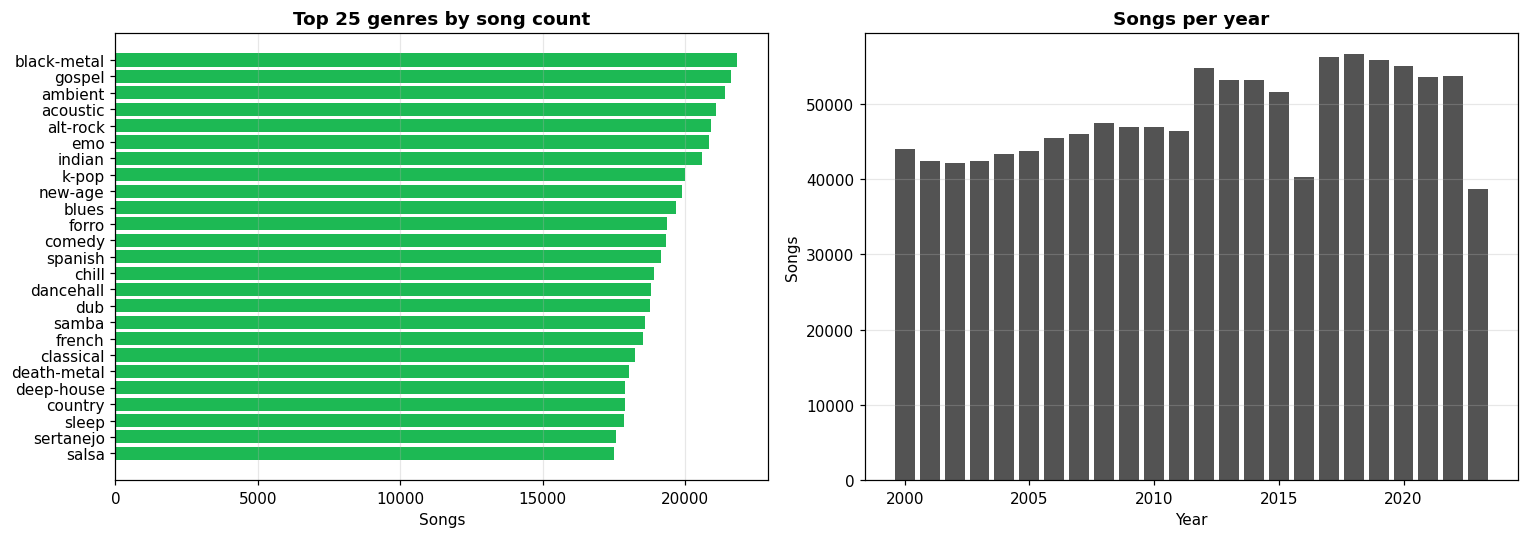

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_genres = df['genre'].value_counts().head(25)
axes[0].barh(top_genres.index[::-1], top_genres.values[::-1], color=PRIMARY)
axes[0].set_title('Top 25 genres by song count')
axes[0].set_xlabel('Songs')
axes[0].grid(axis='x', alpha=0.3)

if 'year' in df.columns:
    year_counts = df['year'].value_counts().sort_index()
    axes[1].bar(year_counts.index, year_counts.values, color=ACCENT, width=0.8)
    axes[1].set_title('Songs per year')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Songs')
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'no year column', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout(); plt.show()

## 2. Audio feature space

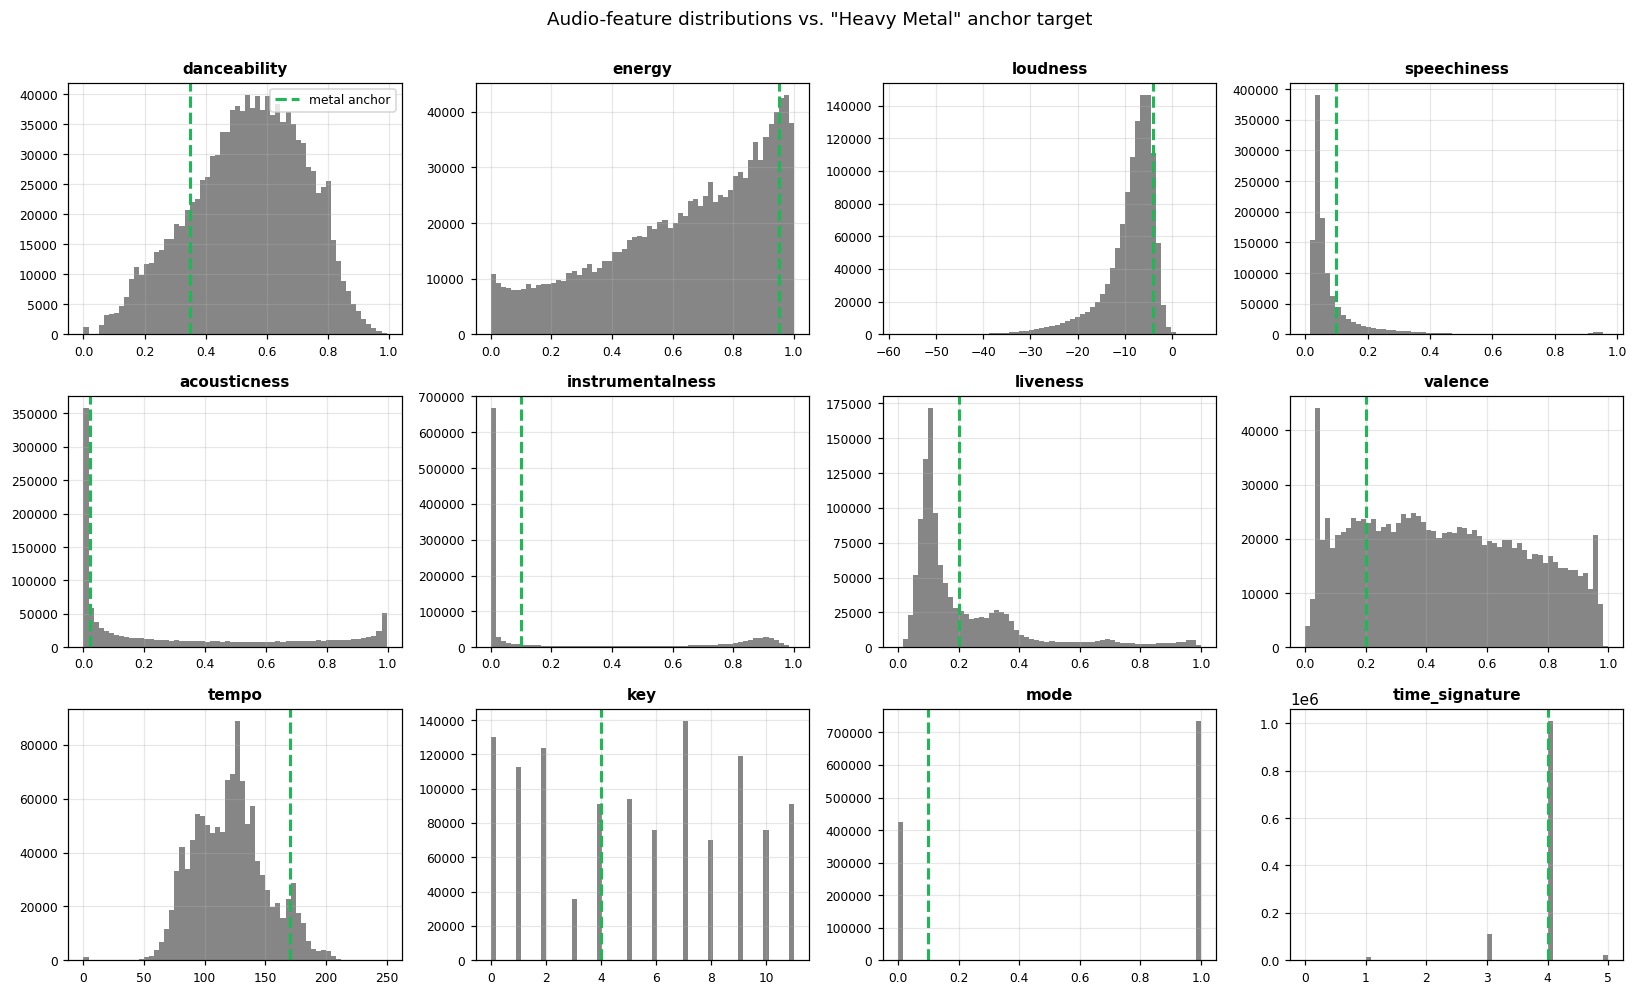

In [4]:
metal_anchor = next(a for a in VIBE_ANCHORS if 'heavy metal' in a['description'])
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, feat in zip(axes.flat, AUDIO_FEATURES):
    vals = df[feat].values
    ax.hist(vals, bins=60, color=ACCENT, alpha=0.7)
    ax.axvline(metal_anchor['features'][feat], color=PRIMARY, lw=2,
               linestyle='--', label='metal anchor')
    ax.set_title(feat, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8, loc='upper right')
fig.suptitle('Audio-feature distributions vs. "Heavy Metal" anchor target',
             fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

## 3. K-Means clustering

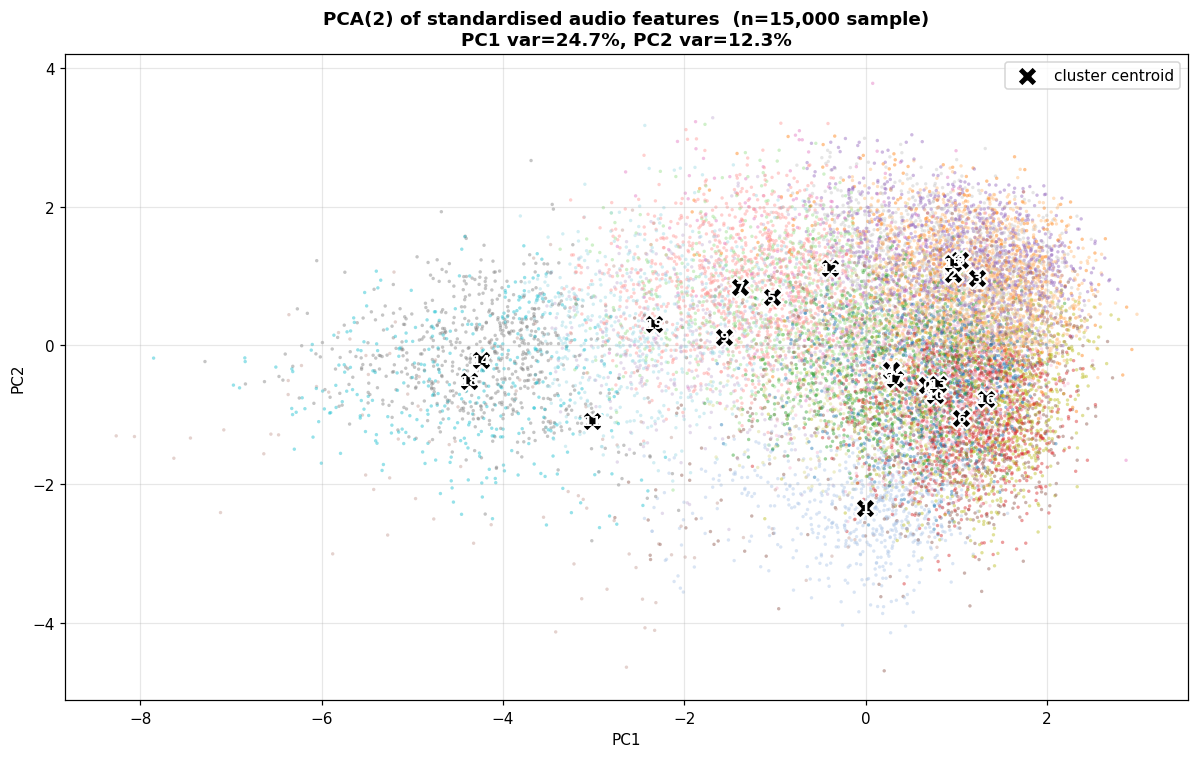

In [5]:
rng = np.random.default_rng(42)
SAMPLE = 15000
idx = rng.choice(len(df), size=SAMPLE, replace=False)

pca_audio = PCA(n_components=2, random_state=42)
pts = pca_audio.fit_transform(audio_features[idx])
labels_sample = df['cluster'].values[idx]

centroids_2d = pca_audio.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(pts[:, 0], pts[:, 1], c=labels_sample, cmap='tab20',
                s=5, alpha=0.45, linewidths=0)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=180,
           c='black', marker='X', linewidths=1.5, edgecolors='white',
           label='cluster centroid', zorder=5)
for i, (x, y) in enumerate(centroids_2d):
    ax.text(x, y, str(i), fontsize=9, ha='center', va='center',
            color='white', weight='bold', zorder=6)
ax.set_title(f'PCA(2) of standardised audio features  (n={SAMPLE:,} sample)\n'
             f'PC1 var={pca_audio.explained_variance_ratio_[0]:.1%}, '
             f'PC2 var={pca_audio.explained_variance_ratio_[1]:.1%}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

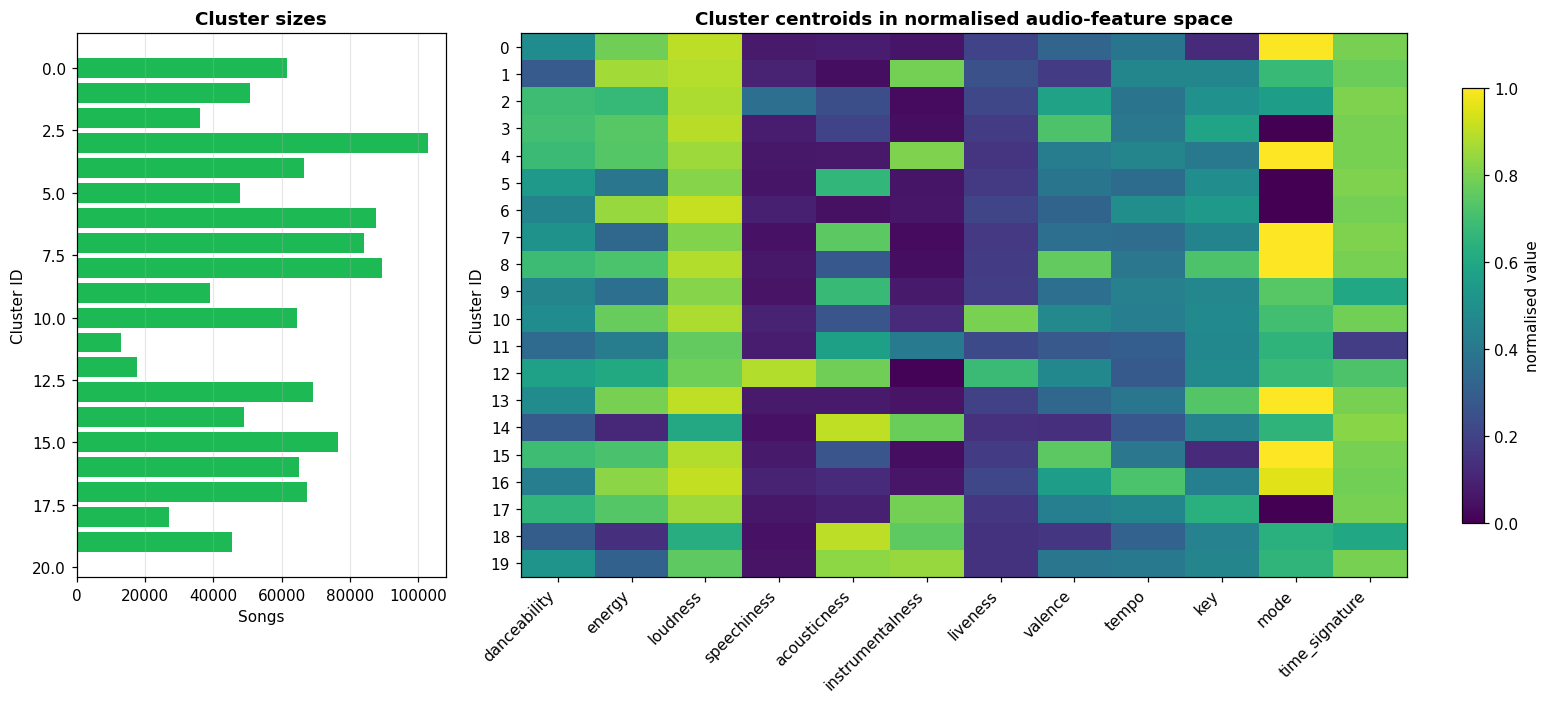

In [6]:
cluster_sizes = df['cluster'].value_counts().sort_index()

centroids_raw = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids_raw, columns=AUDIO_FEATURES)

norm_df = centroid_df.copy()
for f in AUDIO_FEATURES:
    if f == 'key':
        norm_df[f] = centroid_df[f] / 11.0
    else:
        lo = FEATURE_RANGES[f]['min']
        hi = FEATURE_RANGES[f]['max']
        norm_df[f] = (centroid_df[f] - lo) / (hi - lo)
norm_df = norm_df.clip(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5),
                          gridspec_kw={'width_ratios': [1, 3]})

axes[0].barh(cluster_sizes.index, cluster_sizes.values, color=PRIMARY)
axes[0].invert_yaxis()
axes[0].set_title('Cluster sizes')
axes[0].set_xlabel('Songs')
axes[0].set_ylabel('Cluster ID')
axes[0].grid(axis='x', alpha=0.3)

im = axes[1].imshow(norm_df.values, aspect='auto', cmap='viridis')
axes[1].set_xticks(range(len(AUDIO_FEATURES)))
axes[1].set_xticklabels(AUDIO_FEATURES, rotation=45, ha='right')
axes[1].set_yticks(range(kmeans.n_clusters))
axes[1].set_yticklabels(range(kmeans.n_clusters))
axes[1].set_title('Cluster centroids in normalised audio-feature space')
axes[1].set_ylabel('Cluster ID')
fig.colorbar(im, ax=axes[1], shrink=0.8, label='normalised value')

plt.tight_layout(); plt.show()

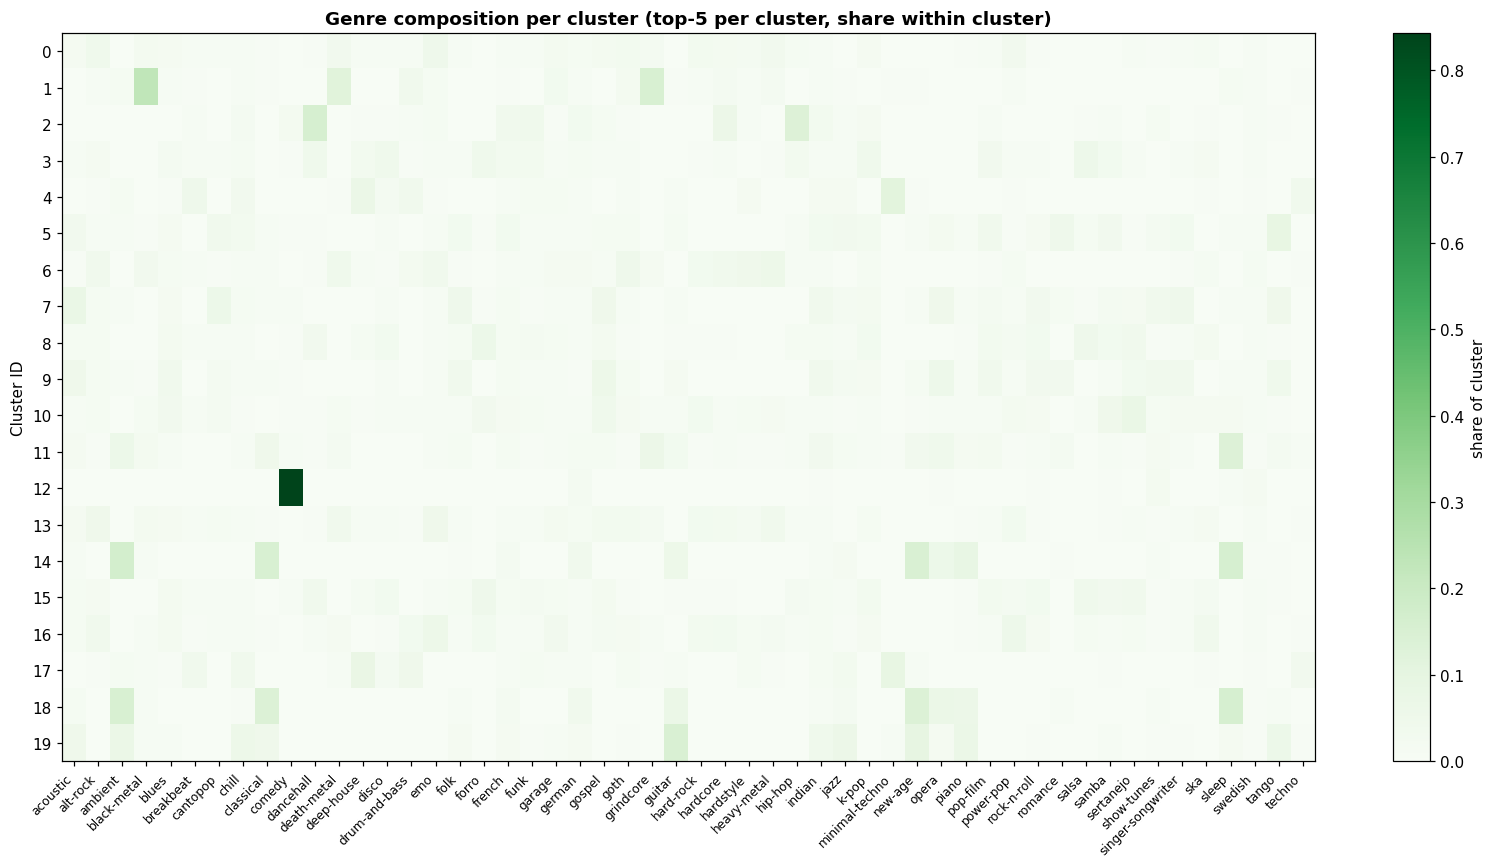

In [7]:
TOP_GENRES_PER_CLUSTER = 5
all_top = set()
cluster_top_lists = {}
for c in range(kmeans.n_clusters):
    g = df[df['cluster'] == c]['genre'].value_counts().head(TOP_GENRES_PER_CLUSTER)
    cluster_top_lists[c] = g
    all_top.update(g.index)

all_top = sorted(all_top)
matrix = np.zeros((kmeans.n_clusters, len(all_top)))
for c in range(kmeans.n_clusters):
    g = df[df['cluster'] == c]['genre'].value_counts()
    total = g.sum()
    for j, gname in enumerate(all_top):
        matrix[c, j] = g.get(gname, 0) / total if total > 0 else 0

fig, ax = plt.subplots(figsize=(15, 8))
im = ax.imshow(matrix, aspect='auto', cmap='Greens')
ax.set_xticks(range(len(all_top)))
ax.set_xticklabels(all_top, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(kmeans.n_clusters))
ax.set_title(f'Genre composition per cluster (top-{TOP_GENRES_PER_CLUSTER} per cluster, share within cluster)')
ax.set_ylabel('Cluster ID')
fig.colorbar(im, ax=ax, label='share of cluster')
plt.tight_layout(); plt.show()

## 4. Vibe anchors

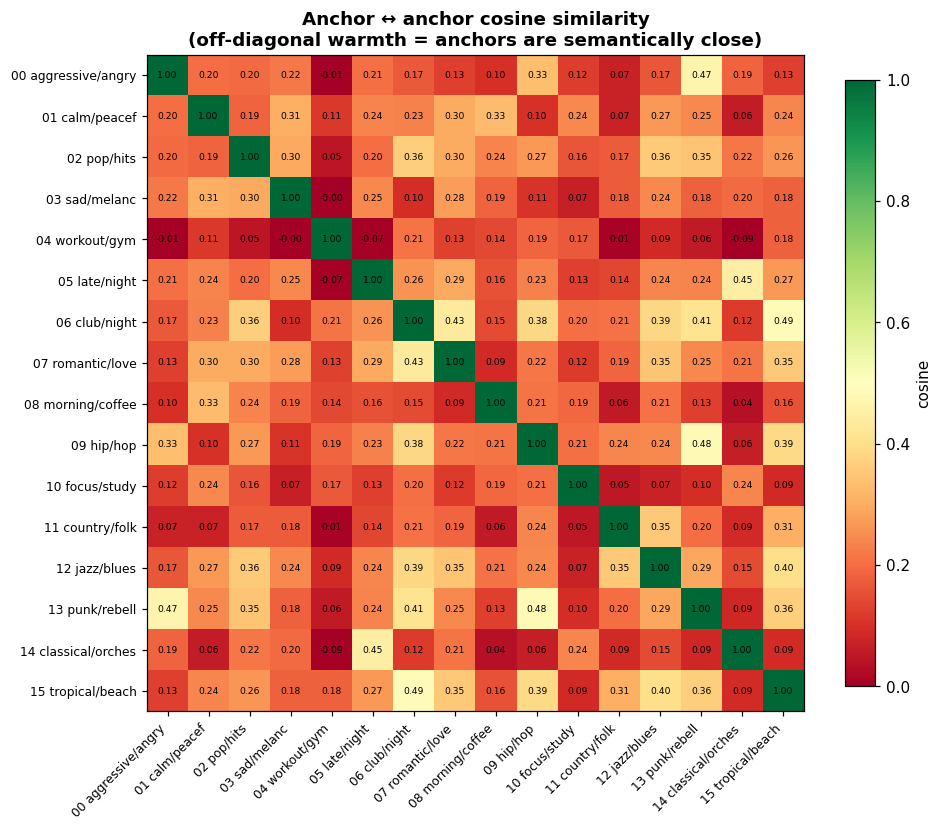

In [8]:
anchor_descriptions = [a['description'] for a in VIBE_ANCHORS]
anchor_short = [d.split()[0] + '/' + d.split()[1][:6] if len(d.split()) > 1 else d.split()[0]
                for d in anchor_descriptions]
anchor_short = [f"{i:02d} {s}" for i, s in enumerate(anchor_short)]

anchor_emb = st_model.encode(anchor_descriptions, show_progress_bar=False)
anchor_sim = cosine_similarity(anchor_emb)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(anchor_sim, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(16)); ax.set_xticklabels(anchor_short, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(16)); ax.set_yticklabels(anchor_short, fontsize=8)
ax.set_title('Anchor ↔ anchor cosine similarity\n(off-diagonal warmth = anchors are semantically close)')
for i in range(16):
    for j in range(16):
        ax.text(j, i, f'{anchor_sim[i,j]:.2f}', ha='center', va='center',
                fontsize=6, color='black')
fig.colorbar(im, ax=ax, shrink=0.8, label='cosine')
plt.tight_layout(); plt.show()

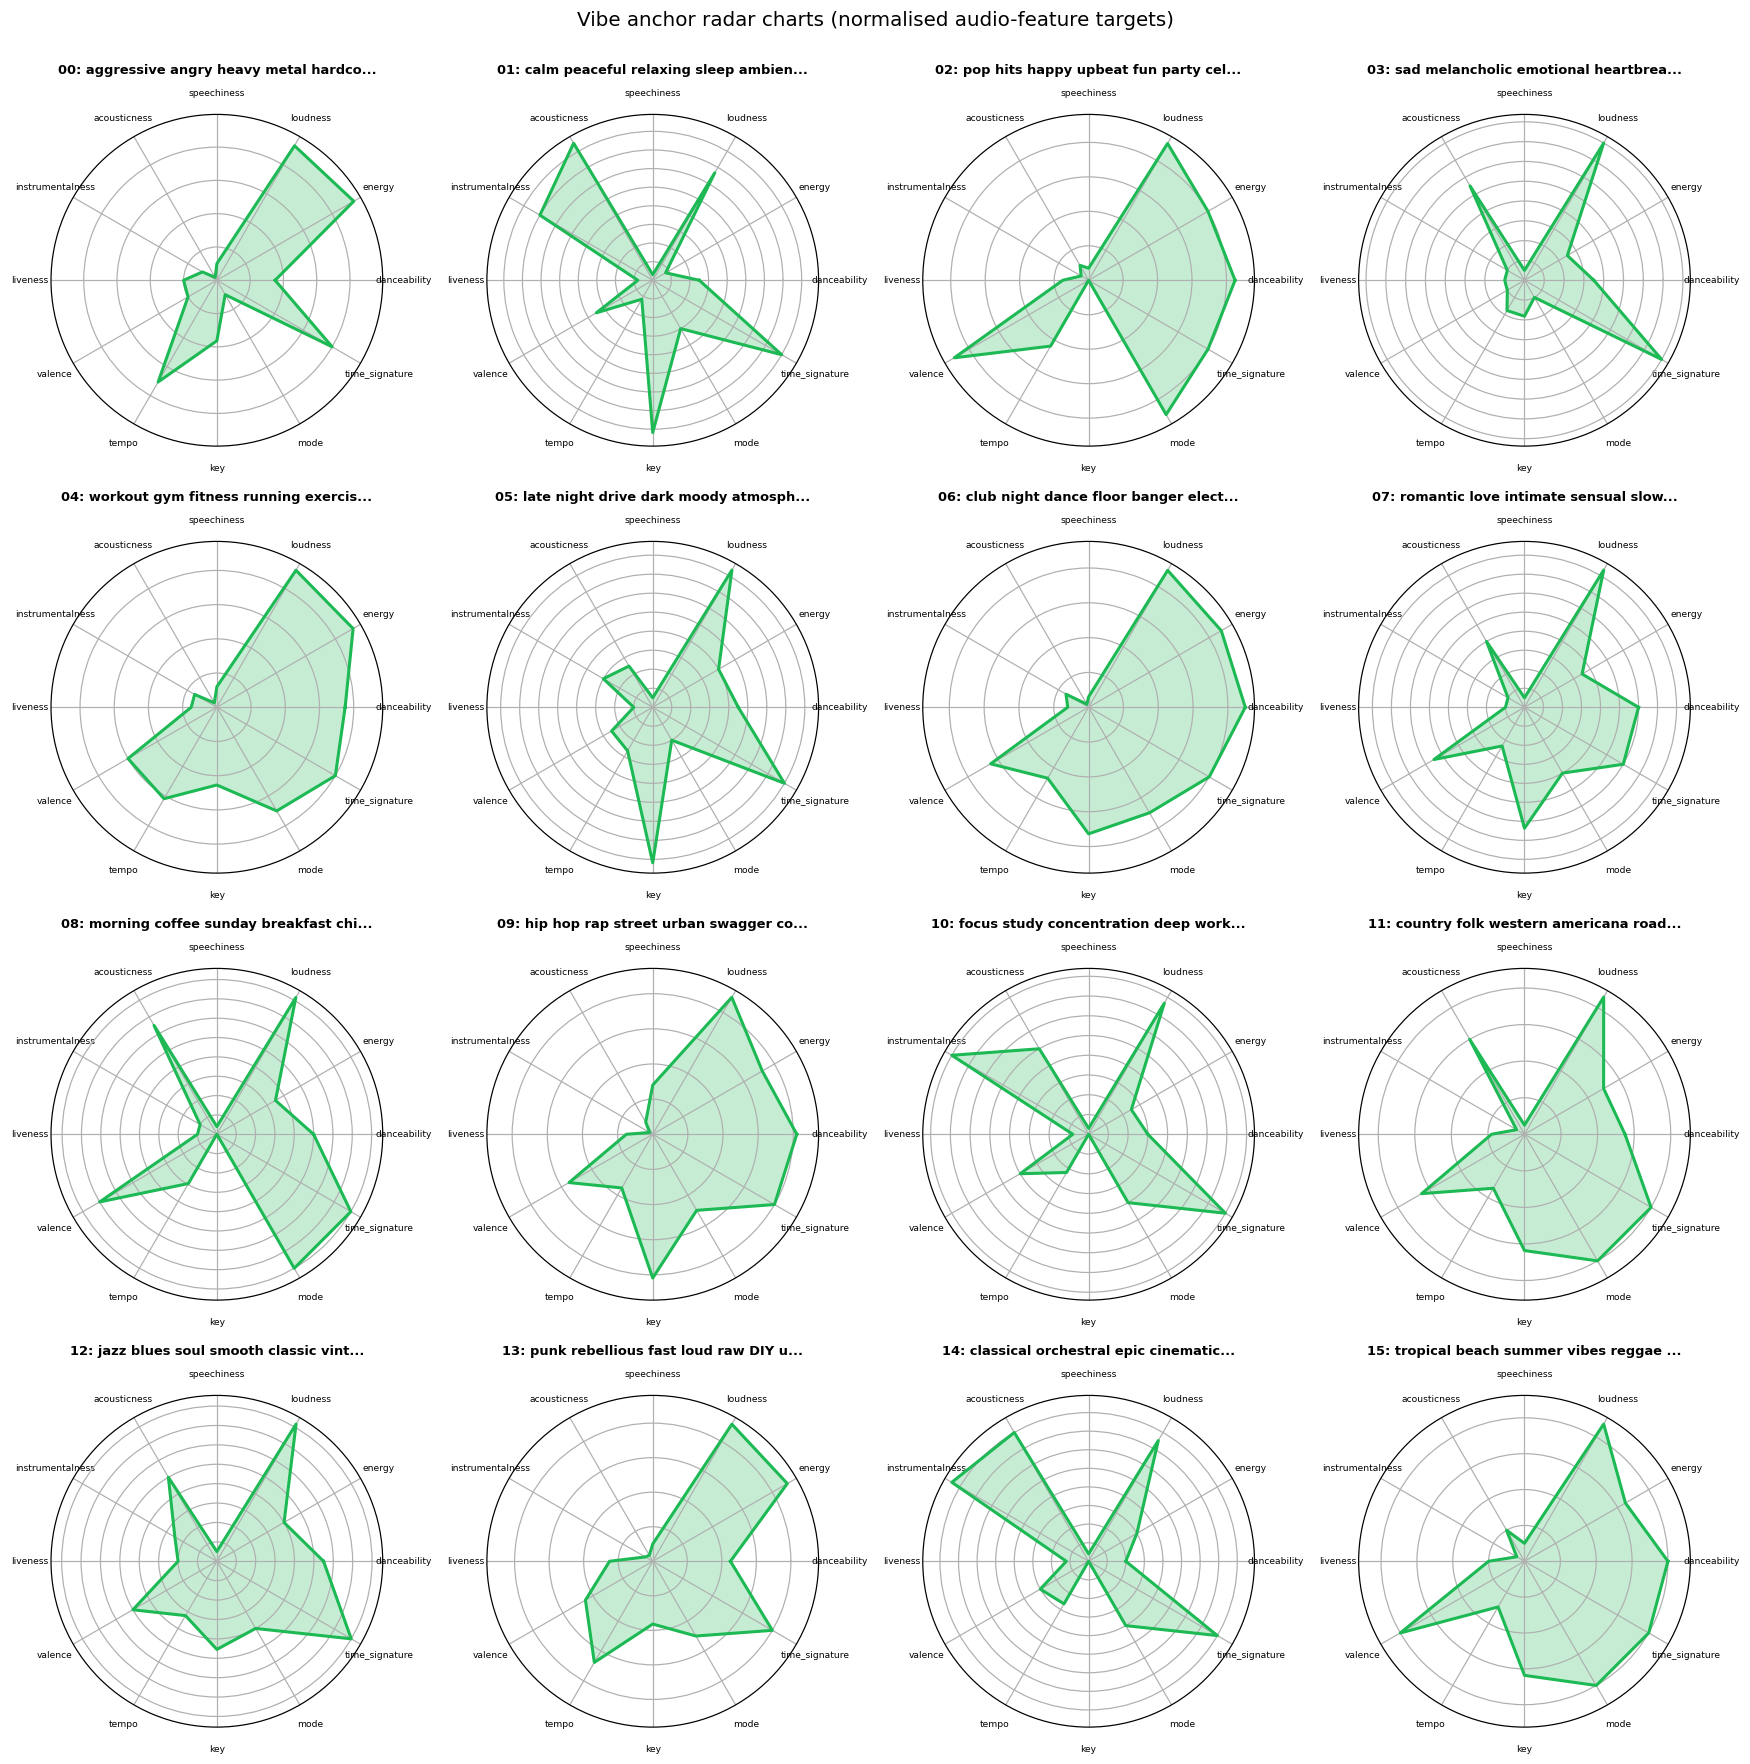

In [9]:
def normalise_anchor_features(feats):
    out = []
    for f in AUDIO_FEATURES:
        v = feats[f]
        if f == 'key':
            out.append(v / 11.0)
        else:
            lo = FEATURE_RANGES[f]['min']
            hi = FEATURE_RANGES[f]['max']
            out.append((v - lo) / (hi - lo))
    return np.clip(out, 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(16, 16),
                          subplot_kw=dict(projection='polar'))
angles = np.linspace(0, 2 * np.pi, len(AUDIO_FEATURES), endpoint=False)
angles_closed = np.concatenate([angles, angles[:1]])
for i, (ax, anchor) in enumerate(zip(axes.flat, VIBE_ANCHORS)):
    vals = normalise_anchor_features(anchor['features'])
    vals_closed = np.concatenate([vals, vals[:1]])
    ax.plot(angles_closed, vals_closed, color=PRIMARY, lw=2)
    ax.fill(angles_closed, vals_closed, color=PRIMARY, alpha=0.25)
    ax.set_xticks(angles)
    ax.set_xticklabels(AUDIO_FEATURES, fontsize=6)
    ax.set_yticklabels([])
    title = anchor['description'][:35] + ('...' if len(anchor['description']) > 35 else '')
    ax.set_title(f"{i:02d}: {title}", fontsize=8.5, pad=10)
fig.suptitle('Vibe anchor radar charts (normalised audio-feature targets)',
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


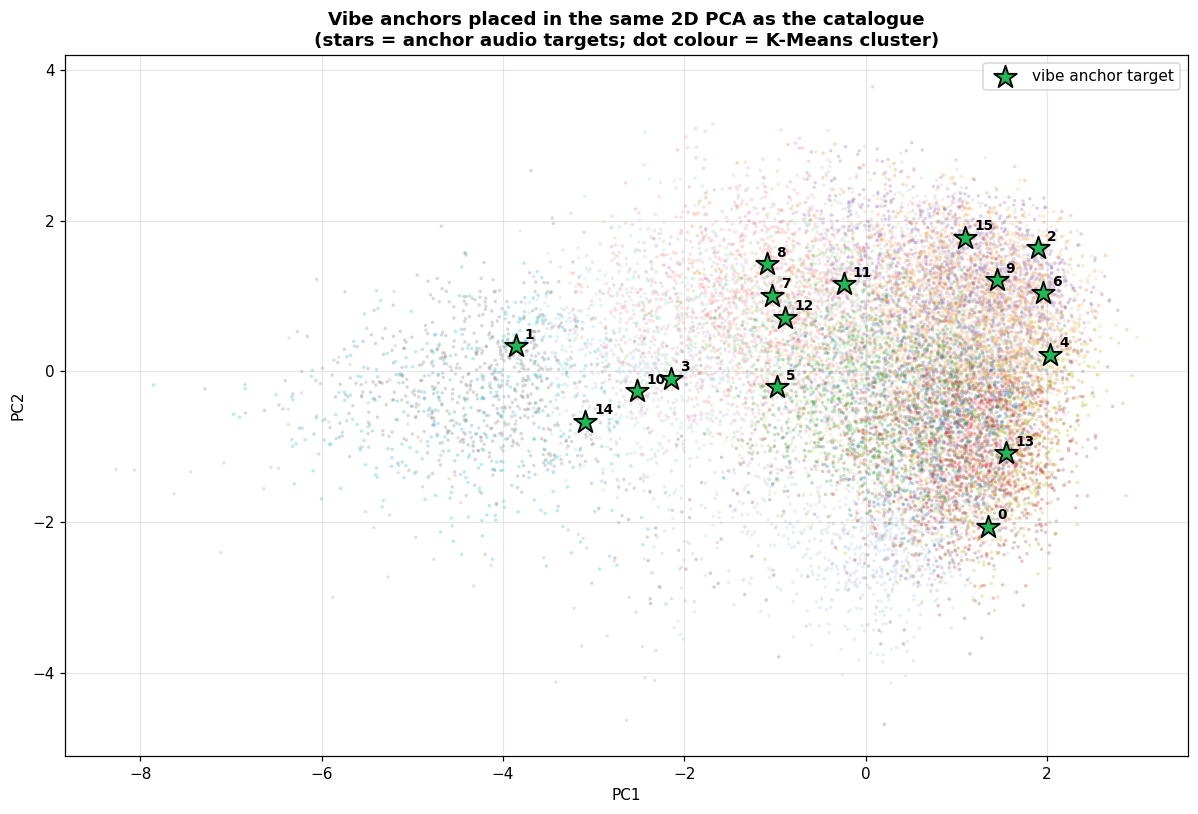

In [10]:
anchor_feature_matrix = np.array([
    [a['features'][f] for f in AUDIO_FEATURES] for a in VIBE_ANCHORS
])
anchor_feature_std = scaler.transform(anchor_feature_matrix)

pca_combined = PCA(n_components=2, random_state=42)
song_pts = pca_combined.fit_transform(audio_features[idx])
anchor_pts = pca_combined.transform(anchor_feature_std)

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.scatter(song_pts[:, 0], song_pts[:, 1], c=labels_sample, cmap='tab20',
           s=5, alpha=0.30, linewidths=0)
ax.scatter(anchor_pts[:, 0], anchor_pts[:, 1], s=240, c=PRIMARY,
           marker='*', edgecolors='black', linewidths=1.2, zorder=5,
           label='vibe anchor target')
for i, (x, y) in enumerate(anchor_pts):
    ax.text(x + 0.1, y + 0.1, str(i), fontsize=9, weight='bold', zorder=6)
ax.set_title('Vibe anchors placed in the same 2D PCA as the catalogue\n'
             '(stars = anchor audio targets; dot colour = K-Means cluster)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Playlist-name routing

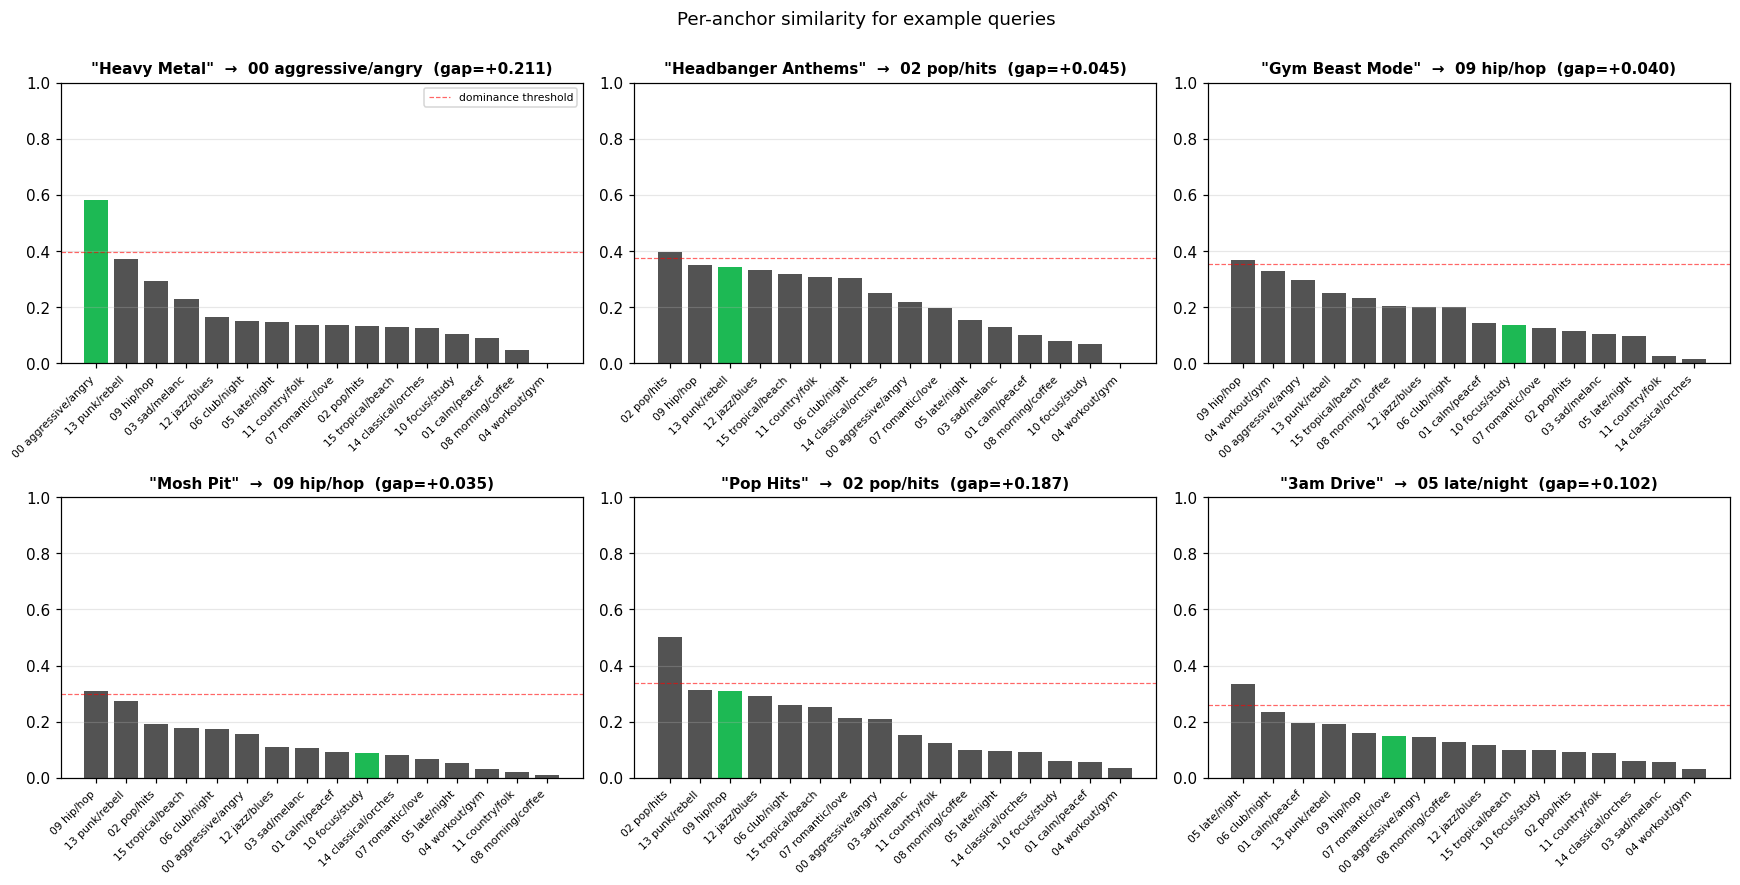

In [11]:
demo_names = ['Heavy Metal', 'Headbanger Anthems', 'Gym Beast Mode',
              'Mosh Pit', 'Pop Hits', '3am Drive']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, name in zip(axes.flat, demo_names):
    vec = st_model.encode([name])
    sims = cosine_similarity(vec, anchor_emb)[0]
    order = np.argsort(sims)[::-1]
    colors = ['#1db954' if i == order[0] else '#535353' for i in range(16)]
    bars = ax.bar(range(16), sims[order], color=[colors[order.tolist().index(i)] for i in range(16) if False] or [colors[i] for i in range(16)])
    bars = ax.bar(range(16), sims[order], color=colors)
    ax.set_xticks(range(16))
    ax.set_xticklabels([anchor_short[i] for i in order], rotation=45, ha='right', fontsize=7)
    top_anchor = anchor_short[order[0]]
    gap = sims[order[0]] - sims[order[1]]
    ax.set_title(f'"{name}"  →  {top_anchor}  (gap={gap:+.3f})', fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.axhline(sims[order[1]] + 0.025, color='red', lw=0.8, ls='--', alpha=0.6,
               label='dominance threshold')
    ax.grid(axis='y', alpha=0.3)
axes[0, 0].legend(fontsize=7, loc='upper right')
fig.suptitle('Per-anchor similarity for example queries', fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

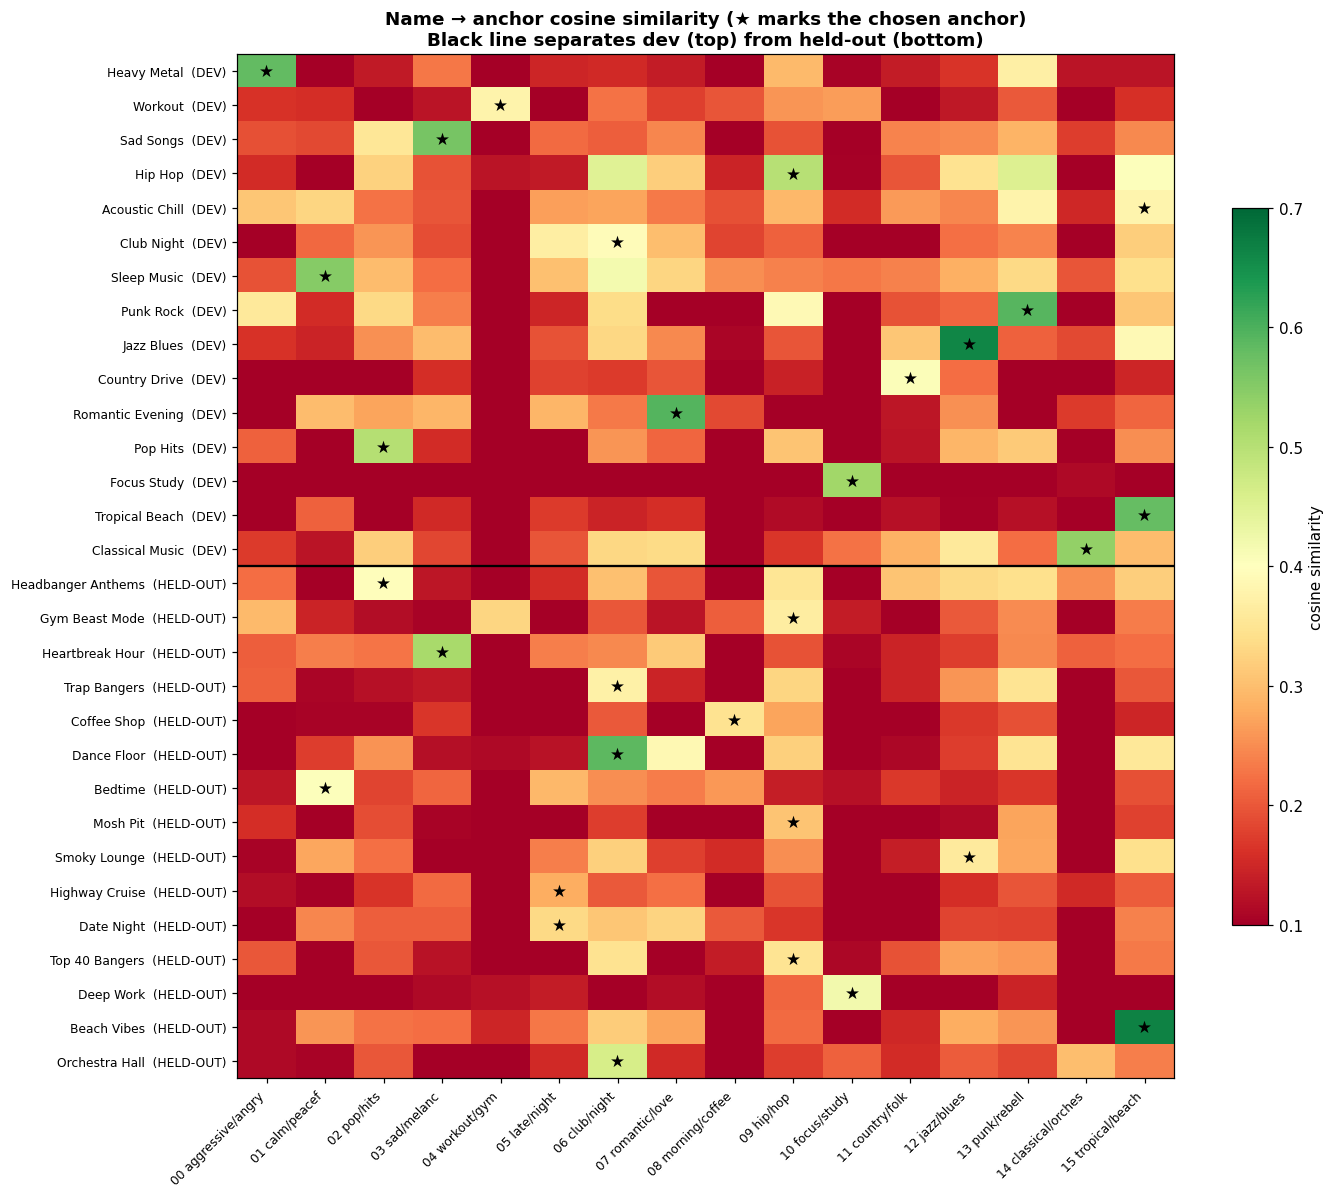

In [12]:
all_names = [tp['name'] for tp in TEST_PLAYLISTS] + [tp['name'] for tp in HELD_OUT_PLAYLISTS]
name_emb = st_model.encode(all_names, show_progress_bar=False)
name_sim = cosine_similarity(name_emb, anchor_emb)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(name_sim, aspect='auto', cmap='RdYlGn', vmin=0.1, vmax=0.7)
ax.set_xticks(range(16)); ax.set_xticklabels(anchor_short, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(all_names)))
ax.set_yticklabels([f'{n}  (DEV)' if i < 15 else f'{n}  (HELD-OUT)'
                    for i, n in enumerate(all_names)], fontsize=8)
for i, n in enumerate(all_names):
    top = int(np.argmax(name_sim[i]))
    ax.text(top, i, '★', ha='center', va='center', fontsize=11, color='black')
ax.axhline(14.5, color='black', lw=1.5)
ax.set_title('Name → anchor cosine similarity (★ marks the chosen anchor)\n'
             'Black line separates dev (top) from held-out (bottom)')
fig.colorbar(im, ax=ax, shrink=0.7, label='cosine similarity')
plt.tight_layout(); plt.show()

## 6. Score-component breakdown

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


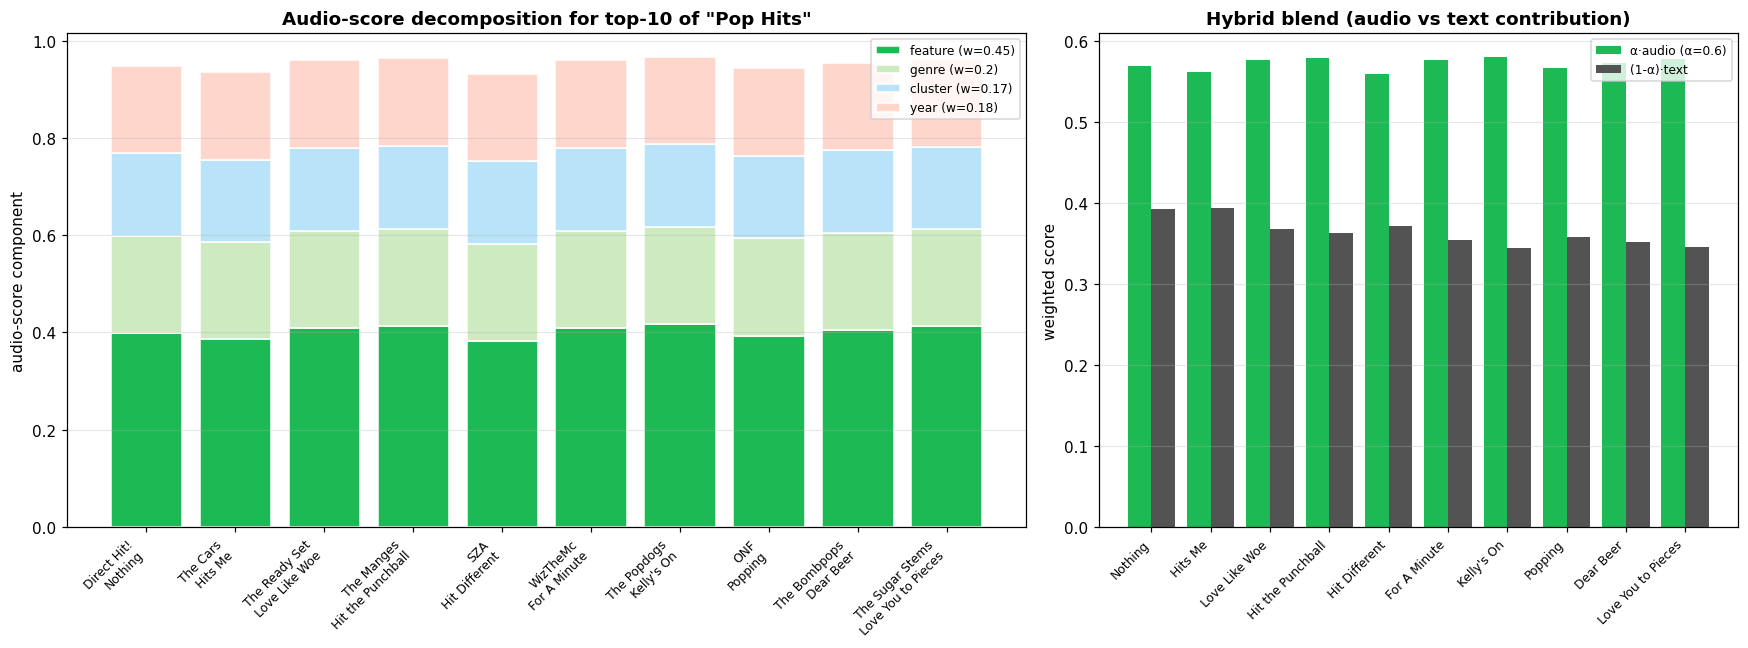

Matched anchor(s): ['pop hits happy upbeat fun party celebration euphoric joyful chart mainstream']


In [13]:
QUERY = 'Pop Hits'
interp = interpret_playlist(QUERY)
rel_clusters = get_relevant_clusters(interp['features'], scaler, kmeans)
year_range = interp['year_range']

feat_target = interp['features']
allowed_genres = interp['genres']

feat_score_arr = np.zeros(len(df))
for f, t in feat_target.items():
    if f == 'key':
        d = np.abs(df[f].values.astype(float) - t)
        c = 1.0 - np.minimum(d, 12.0 - d) / 6.0
    elif f not in FEATURE_RANGES:
        continue
    else:
        lo = FEATURE_RANGES[f]['min']; hi = FEATURE_RANGES[f]['max']
        c = 1.0 - np.abs((df[f].values - lo) / (hi - lo) - (t - lo) / (hi - lo))
    feat_score_arr += c
feat_score_arr /= len(feat_target)

keywords = {p for g in allowed_genres for p in g.replace('-', ' ').split() if len(p) >= 3}
if keywords:
    genre_mask_arr = df['genre'].str.contains('|'.join(keywords), case=False, na=False).values.astype(float)
else:
    genre_mask_arr = df['genre'].isin(allowed_genres).values.astype(float)
cluster_mask_arr = df['cluster'].isin(rel_clusters).values.astype(float)
year_score_arr = (score_songs_by_year(df, year_range) if year_range and 'year' in df.columns
                   else np.zeros(len(df)))

audio_total = score_songs_by_audio(df, feat_target, allowed_genres, rel_clusters, year_range)
name_vec = create_playlist_embedding(QUERY)
text_sim = cosine_similarity(name_vec, text_embeddings)[0]
text_norm = (text_sim - text_sim.min()) / (text_sim.max() - text_sim.min() + 1e-8)
ALPHA = 0.6
final = ALPHA * audio_total + (1 - ALPHA) * text_norm
top10 = np.argsort(final)[-10:][::-1]

use_year = year_range is not None
if use_year:
    weights = (0.45, 0.20, 0.17, 0.18)
    comps = ['feature', 'genre', 'cluster', 'year']
    comp_arrays = [feat_score_arr, genre_mask_arr, cluster_mask_arr, year_score_arr]
else:
    weights = (0.55, 0.25, 0.20)
    comps = ['feature', 'genre', 'cluster']
    comp_arrays = [feat_score_arr, genre_mask_arr, cluster_mask_arr]

labels_x = [f'{df.iloc[i].artist_name[:18]}\n{df.iloc[i].track_name[:22]}' for i in top10]
stack = np.stack([w * arr[top10] for w, arr in zip(weights, comp_arrays)])
audio_part = ALPHA * audio_total[top10]
text_part = (1 - ALPHA) * text_norm[top10]

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [3, 2]})

bottom = np.zeros(10)
colors_components = ['#1db954', '#cdeac0', '#b9e3f9', '#ffd6cc']
for i, c in enumerate(comps):
    axes[0].bar(range(10), stack[i], bottom=bottom, color=colors_components[i],
                edgecolor='white', label=f'{c} (w={weights[i]})')
    bottom += stack[i]
axes[0].set_xticks(range(10)); axes[0].set_xticklabels(labels_x, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('audio-score component')
axes[0].set_title(f'Audio-score decomposition for top-10 of "{QUERY}"')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

x = np.arange(10)
axes[1].bar(x - 0.2, audio_part, width=0.4, color=PRIMARY, label=f'α·audio (α={ALPHA})')
axes[1].bar(x + 0.2, text_part, width=0.4, color=ACCENT, label=f'(1-α)·text')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([df.iloc[i].track_name[:18] for i in top10], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Hybrid blend (audio vs text contribution)')
axes[1].set_ylabel('weighted score')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Matched anchor(s): {interp["matched_anchors"]}')

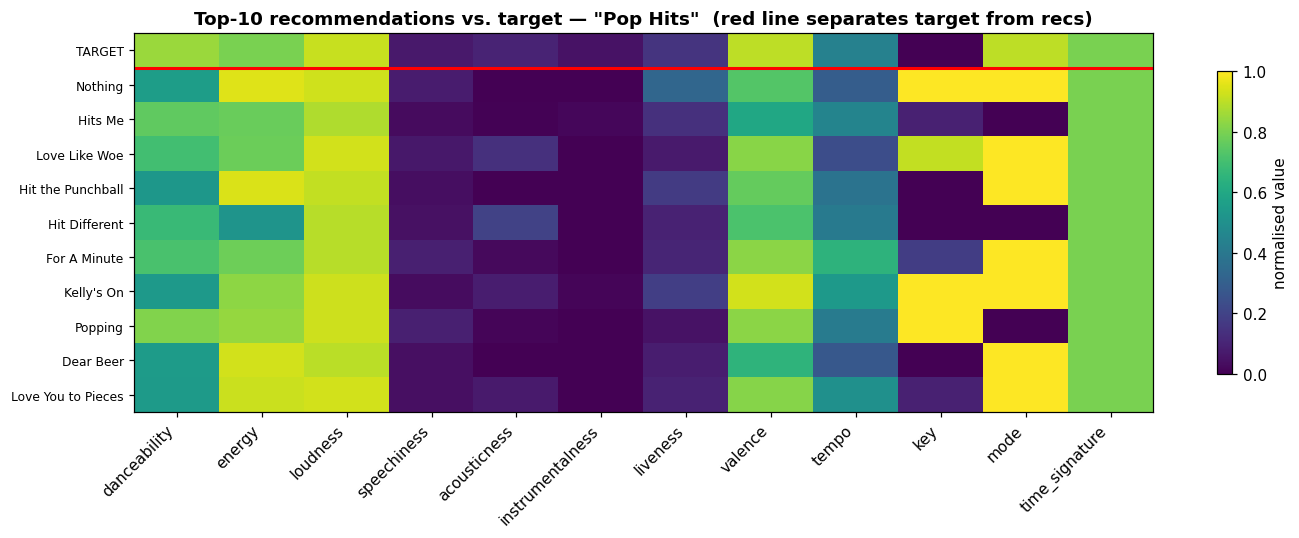

In [14]:
rec_features = np.zeros((10, len(AUDIO_FEATURES)))
target_norm = np.array([
    (feat_target[f] - FEATURE_RANGES[f]['min']) / (FEATURE_RANGES[f]['max'] - FEATURE_RANGES[f]['min'])
    if f != 'key' else feat_target[f] / 11.0
    for f in AUDIO_FEATURES
])
for j, idx_song in enumerate(top10):
    for k, f in enumerate(AUDIO_FEATURES):
        v = df.iloc[idx_song][f]
        if f == 'key':
            rec_features[j, k] = v / 11.0
        else:
            lo = FEATURE_RANGES[f]['min']; hi = FEATURE_RANGES[f]['max']
            rec_features[j, k] = (v - lo) / (hi - lo)

matrix_with_target = np.vstack([target_norm[None, :], rec_features])
row_labels = [f'TARGET'] + [df.iloc[i].track_name[:30] for i in top10]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(matrix_with_target, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(AUDIO_FEATURES)))
ax.set_xticklabels(AUDIO_FEATURES, rotation=45, ha='right')
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)
ax.axhline(0.5, color='red', lw=2)
ax.set_title(f'Top-10 recommendations vs. target — "{QUERY}"  (red line separates target from recs)')
fig.colorbar(im, ax=ax, shrink=0.8, label='normalised value')
plt.tight_layout(); plt.show()

## 7. End-to-end recommendation showcase

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


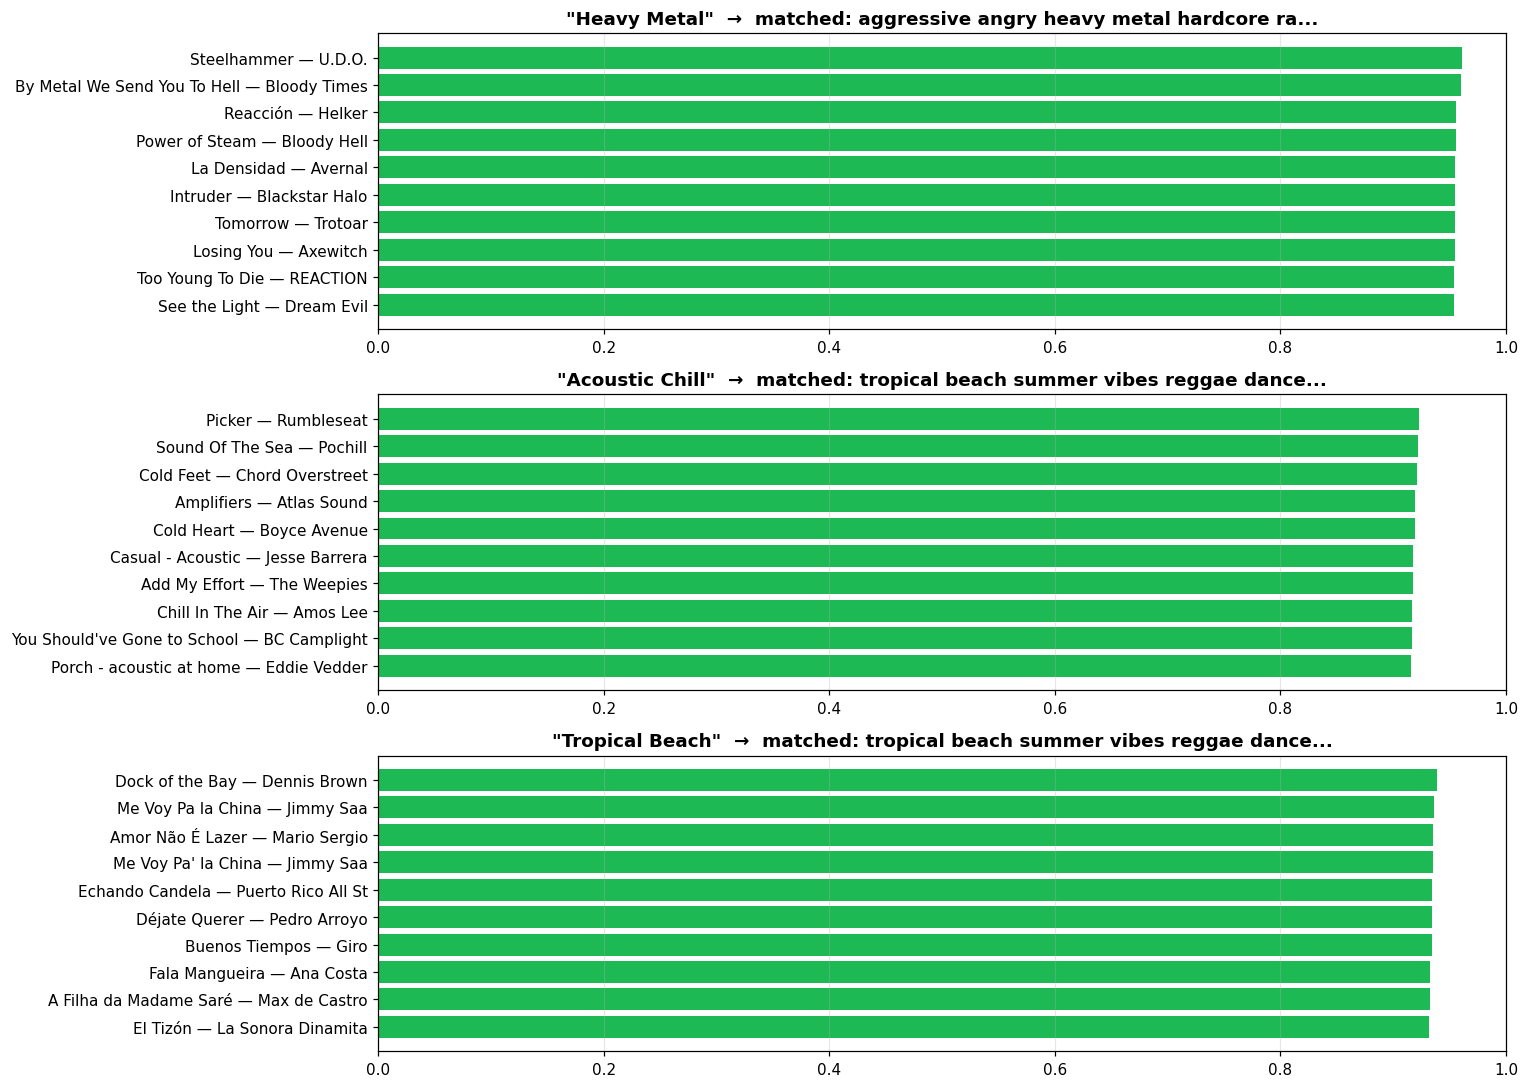

In [15]:
showcases = ['Heavy Metal', 'Acoustic Chill', 'Tropical Beach']
fig, axes = plt.subplots(len(showcases), 1, figsize=(14, 10))
if len(showcases) == 1:
    axes = [axes]
for ax, name in zip(axes, showcases):
    recs, interp_q = recommend(name, df, text_embeddings, top_k=10,
                                scaler=scaler, kmeans=kmeans)
    labels_y = [f'{r.track_name[:32]} — {r.artist_name[:18]}' for r in recs.itertuples()]
    ax.barh(labels_y[::-1], recs['score'].values[::-1], color=PRIMARY)
    ax.set_title(f'"{name}"  →  matched: {interp_q["matched_anchors"][0][:40]}...')
    ax.set_xlim(0, 1.0); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Custom NN encoder embedding space

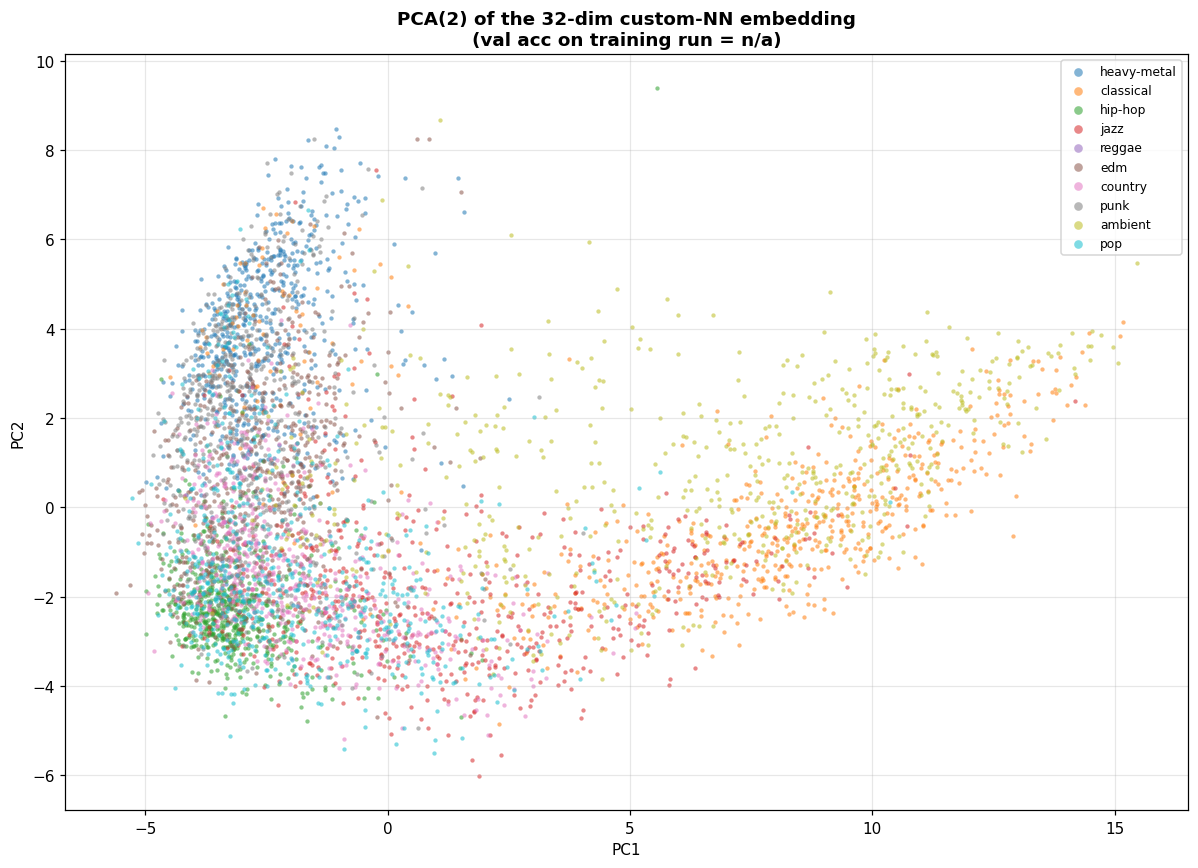

In [16]:
from src.custom_encoder import train_or_load
custom_encoder, custom_info, custom_embeddings = train_or_load(
    df, audio_features, model_path='models/custom_encoder.pt',
    emb_path='data/custom_audio_embeddings.npy', verbose=False,
)

VIZ_GENRES = ['heavy-metal', 'classical', 'hip-hop', 'jazz', 'reggae',
              'edm', 'country', 'punk', 'ambient', 'pop']

viz_idx = []
PER_GENRE = 600
for g in VIZ_GENRES:
    sel = df.index[df['genre'] == g].tolist()
    if len(sel) > PER_GENRE:
        sel = list(np.random.default_rng(42).choice(sel, PER_GENRE, replace=False))
    viz_idx.extend(sel)
viz_idx = np.array(viz_idx, dtype=int)

pca_nn = PCA(n_components=2, random_state=42)
pts_nn = pca_nn.fit_transform(custom_embeddings[viz_idx])
genres_arr = df.iloc[viz_idx]['genre'].values

fig, ax = plt.subplots(figsize=(11, 8))
cmap = plt.colormaps['tab10']
for i, g in enumerate(VIZ_GENRES):
    mask = (genres_arr == g)
    ax.scatter(pts_nn[mask, 0], pts_nn[mask, 1], s=8, alpha=0.55,
               color=cmap(i / 10), label=g, linewidths=0)
ax.set_title('PCA(2) of the 32-dim custom-NN embedding\n'
             f'(val acc on training run = {custom_info.get("final_val_acc", "n/a")})')
ax.legend(fontsize=8, markerscale=2.0, loc='upper right')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Anchors vs cluster centroids alignment

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


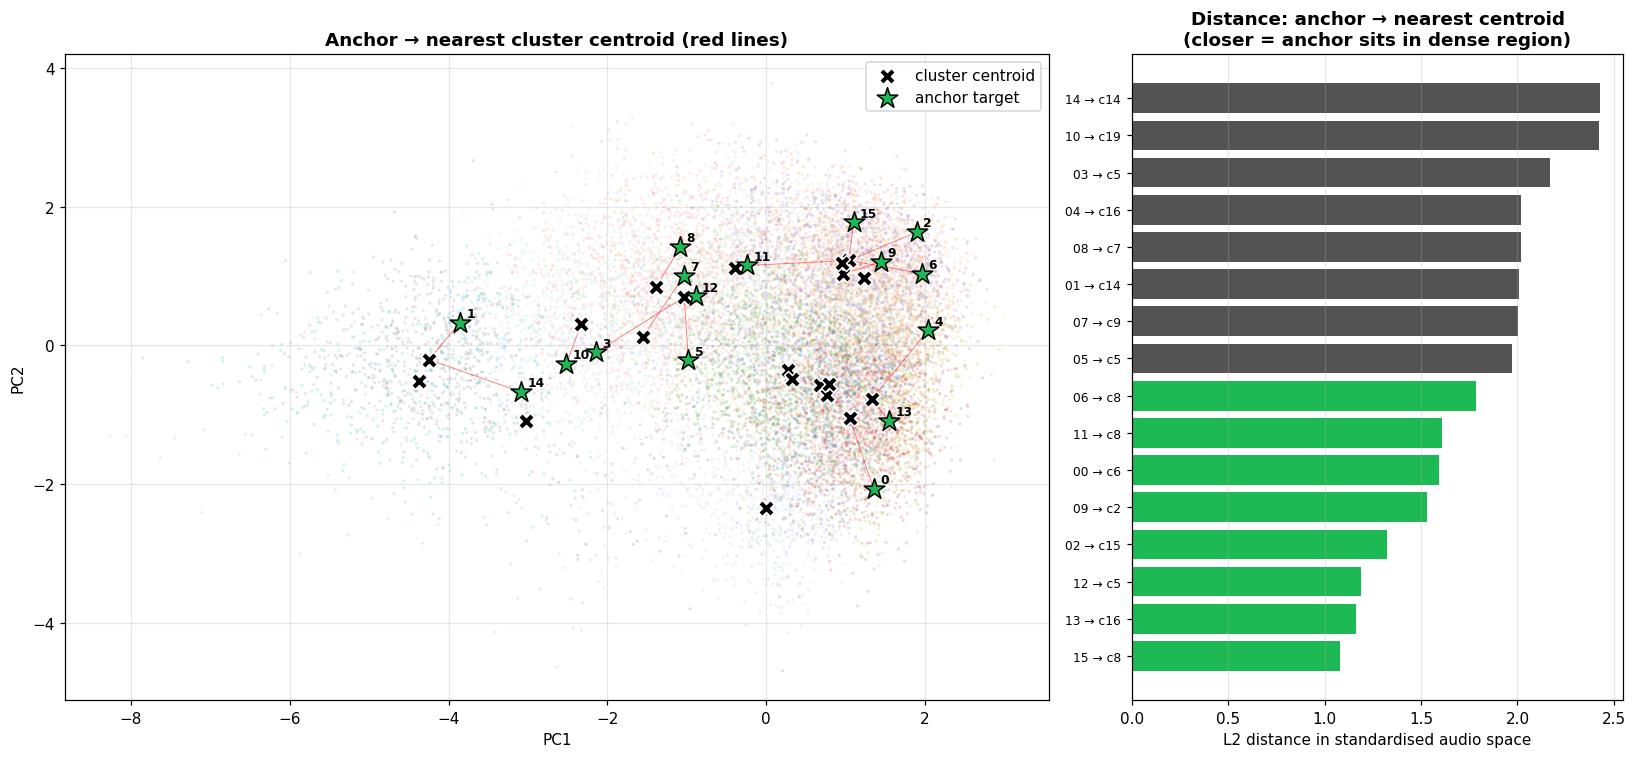

In [17]:
centroid_std = kmeans.cluster_centers_
anchor_std = scaler.transform(anchor_feature_matrix)
dists = np.linalg.norm(anchor_std[:, None, :] - centroid_std[None, :, :], axis=2)
nearest_cluster = dists.argmin(axis=1)
nearest_dist = dists.min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 7),
                          gridspec_kw={'width_ratios': [2, 1]})

song_pca = pca_combined.fit_transform(audio_features[idx])
anchor_pca = pca_combined.transform(anchor_std)
centroid_pca = pca_combined.transform(centroid_std)
axes[0].scatter(song_pca[:, 0], song_pca[:, 1], c=labels_sample, cmap='tab20',
                s=4, alpha=0.20, linewidths=0)
axes[0].scatter(centroid_pca[:, 0], centroid_pca[:, 1], s=110, c='black',
                marker='X', edgecolors='white', linewidths=1.0,
                label='cluster centroid', zorder=4)
axes[0].scatter(anchor_pca[:, 0], anchor_pca[:, 1], s=200, c=PRIMARY,
                marker='*', edgecolors='black', linewidths=1.0,
                label='anchor target', zorder=5)
for i in range(16):
    nc = nearest_cluster[i]
    axes[0].plot([anchor_pca[i, 0], centroid_pca[nc, 0]],
                 [anchor_pca[i, 1], centroid_pca[nc, 1]],
                 color='red', lw=0.6, alpha=0.5, zorder=3)
    axes[0].text(anchor_pca[i, 0] + 0.08, anchor_pca[i, 1] + 0.08,
                 str(i), fontsize=8, weight='bold', zorder=6)
axes[0].set_title('Anchor → nearest cluster centroid (red lines)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

order_d = np.argsort(nearest_dist)
axes[1].barh(range(16), nearest_dist[order_d],
             color=[PRIMARY if d < np.median(nearest_dist) else ACCENT
                    for d in nearest_dist[order_d]])
axes[1].set_yticks(range(16))
axes[1].set_yticklabels([f"{i:02d} → c{nearest_cluster[i]}" for i in order_d], fontsize=8)
axes[1].set_title('Distance: anchor → nearest centroid\n(closer = anchor sits in dense region)')
axes[1].set_xlabel('L2 distance in standardised audio space')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()